We consider a quantum many-body system consisting of collectively interacting spins coupled to a single-mode cavity field. The spin sector is described by the Lipkin–Meshkov–Glick (LMG) model, while the cavity mode interacts collectively with the spins through a Dicke-type light–matter coupling. The total Hamiltonian is give
\begin{align}
\hat{H}_{\text{total}} &= \hat{H}_{\text{LMG}} + \hat{H}_{\text{D}}, \\
\hat{H}_{\text{LMG}} &= -\frac{J}{N-1}\sum_{i,j} \hat{\sigma}^{z}_{i}\hat{\sigma}^{z}_{j} + 2h(t)\hat{S}_x + \hbar\omega_{{0}}\hat{a}^{\dagger}\hat{a}\\
&= -\frac{2J}{N-1}\hat{S_z^2} + 2h(t)\hat{S}_x + \hbar\omega_{0}\hat{a}^{\dagger}\hat{a}\\
\hat{H}_{\text{D}} &= \frac{2g}{\sqrt{N}}(\hat{a} + \hat{a}^{\dagger}) \hat{S}_z, \\
h(t) &= h\cos{\omega t},
\end{align}

$[\hat{S}^2, \hat{H}(t)] = 0$

Ref.
[1] Ising model in a light-induced quantized transverse field: https://doi.org/10.1103/PhysRevResearch.2.023131

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from qutip import *
import numpy as np
from scipy.special import jn_zeros

def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N/2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    #H2 = hbar * omega0 /(N-1) * (adag_full * a_full)
    H2 = hbar * omega0 * (adag_full * a_full)
    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sz_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx

def run_dynamics_lmg(args):
    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    omega = args['omega']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)
    H_td = [H0 + H2 + H_int, [H1,h_t]]

    T = 2*np.pi/omega
    f_modes_0, f_energies = floquet_modes(H_td, T, args)
    #f_modes_0 = np.array(f_modes_0)

    #Inverse Participation Ratio (IPR) calculation
    #ipr = np.sum(np.abs(f_modes_0)**4, axis=0)

    return f_modes_0

100%|██████████| 6/6 [00:00<00:00, 11.42it/s]


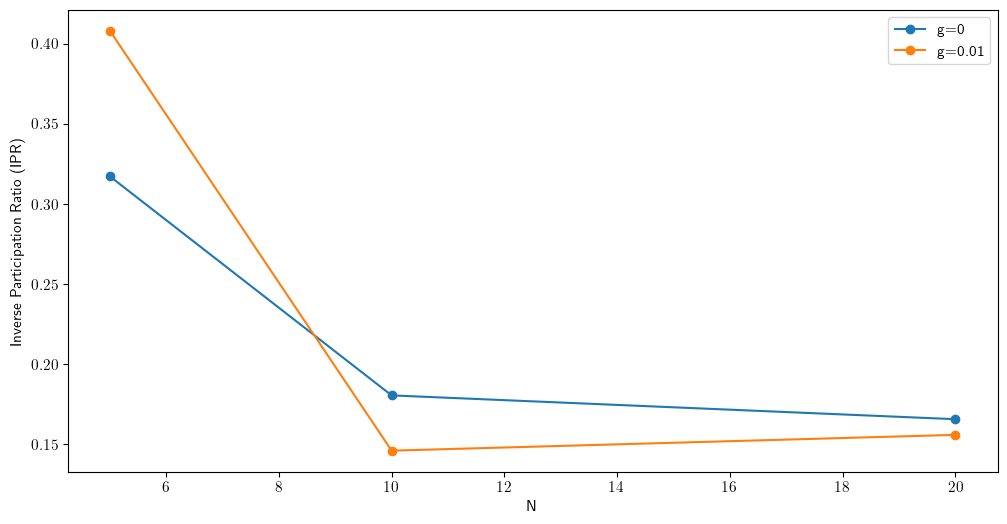

In [ ]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm
import numpy as np

plt.rcParams.update({"figure.figsize": (12,6), "font.size": 11, "text.usetex": True})

omega = 0.7
hbar = 1.0
h0 = 0
n_ph = 5
omega0 = 1.0
Jvalue = 1.0

gvals = [0, 0.01]
Nvals = [5, 10, 20]
opts = Options(nsteps=int(1e5))

T = 2*np.pi/omega
tlist = np.linspace(0, 200*T, 1000)
h = jn_zeros(0,5)[1] * omega / 4.0

all_args = []
for g in gvals:
    for N in Nvals:
        all_args.append({'tlist': tlist, 'N': N, 'n_ph': n_ph, 'g': g, 'hbar': hbar, 'omega0': omega0, 'Jvalue': Jvalue, 'h0': h0, 'h': h, 'omega': omega, 'opts': opts})

    with Pool(processes=5) as p:
         results = list(tqdm(p.imap(run_dynamics_lmg, all_args), total=len(all_args)))

    ipr_values = []
    for f_modes_0 in results:
        ipr = np.sum(np.abs(f_modes_0[0].full())**4, axis=0)
        ipr_values.append(ipr)

plt.plot(Nvals, ipr_values[0:3], label = f'g={gvals[0]}', marker='o')
plt.plot(Nvals, ipr_values[3:6], label = f'g={gvals[1]}', marker='o')
plt.xlabel('N')
plt.ylabel('Inverse Participation Ratio (IPR)')
#plt.title('IPR vs N for different g values')
plt.legend()

plt.show()

In [4]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from qutip import *
import numpy as np
from scipy.special import jn_zeros

def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N/2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    #H2 = hbar * omega0 /(N-1) * (adag_full * a_full)
    H2 = hbar * omega0 * (adag_full * a_full)
    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sz_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx

def run_dynamics_lmg(args):
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    omega = args['omega']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)
    H_td = [H0 + H2 + H_int, [H1,h_t]]

    T = 2*np.pi/omega
    f_modes_0, f_energies = floquet_modes(H_td, T, args)

    return f_modes_0

/home/mahi/anaconda3/envs/p14/lib/python3.14/site-packages/qutip/solver/floquet_bwcomp.py:37: FutureWarning: `floquet_modes` is deprecated. Use `FloquetBasis.mode` instead.
  warnings.warn(FutureWarning(
/home/mahi/anaconda3/envs/p14/lib/python3.14/site-packages/qutip/solver/floquet_bwcomp.py:37: FutureWarning: `floquet_modes` is deprecated. Use `FloquetBasis.mode` instead.
  warnings.warn(FutureWarning(
/home/mahi/anaconda3/envs/p14/lib/python3.14/site-packages/qutip/solver/floquet_bwcomp.py:37: FutureWarning: `floquet_modes` is deprecated. Use `FloquetBasis.mode` instead.
  warnings.warn(FutureWarning(
/home/mahi/anaconda3/envs/p14/lib/python3.14/site-packages/qutip/solver/floquet_bwcomp.py:37: FutureWarning: `floquet_modes` is deprecated. Use `FloquetBasis.mode` instead.
  warnings.warn(FutureWarning(
/home/mahi/anaconda3/envs/p14/lib/python3.14/site-packages/qutip/solver/floquet_bwcomp.py:37: FutureWarning: `floquet_modes` is deprecated. Use `FloquetBasis.mode` instead.
  warnings.

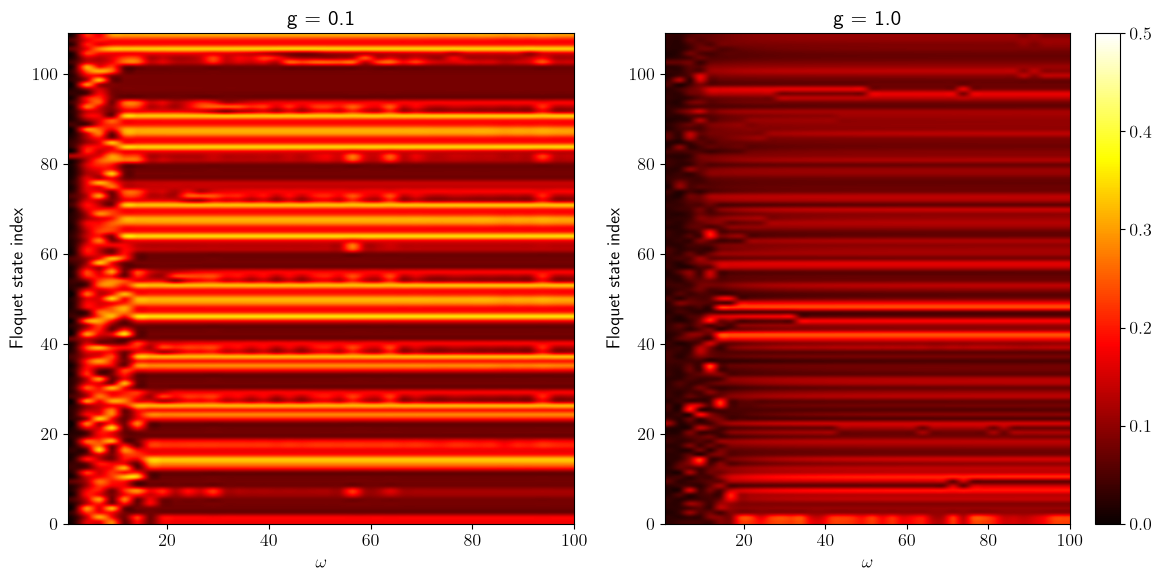

In [5]:
import matplotlib.pyplot as plt
from multiprocess import Pool
from tqdm import tqdm
import numpy as np

plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 13, "text.usetex": True})

hbar = 1.0
h0 = 0
n_ph = 10
omega0 = 1.0
Jvalue = 1.0
gvals = [0.1, 1.0]

N = 10
#opts = Options(nsteps=int(1e10))

omegas = np.linspace(0.5, 100.0, 40)
hs = jn_zeros(0, 5)[1] * omegas / 4.0

nprocs = 10
fig, axs = plt.subplots(1, len(gvals), figsize=(12, 6), squeeze=False)

if __name__ == "__main__":

    for ax, g in zip(axs[0], gvals):
        params = [
            {
                'N': N, 'n_ph': n_ph, 'g': g, 'hbar': hbar, 'omega0': omega0,
                'Jvalue': Jvalue, 'h0': h0, 'h': h, 'omega': omega
            }
            for h, omega in zip(hs, omegas)
        ]

        with Pool(processes=min(nprocs, len(params))) as pool:
            results = list(tqdm(pool.imap(run_dynamics_lmg, params), total=len(params)))

        n_states = len(results[0])
        iprmat = np.zeros((n_states, len(results)))

        for j, floquet_states in enumerate(results):
            for i, state in enumerate(floquet_states):
                vec = state.full().ravel()
                iprmat[i, j] = np.sum(np.abs(vec)**4)

        im = ax.imshow(
            iprmat,
            aspect="auto",
            interpolation="spline16",
            cmap="hot",
            origin="lower",
            extent=[omegas[0], omegas[-1], 0, n_states - 1],
            vmax=0.5,
            vmin=0
        )
        
        ax.set_xlabel(r'$\omega$')
        ax.set_title(f'g = {g}')
        ax.set_ylabel('Floquet state index')

    fig.colorbar(im, ax=ax, orientation='vertical', shrink=1)
    plt.tight_layout()
    plt.show()
